# Preprocesamiento Textual

In [1]:
!pip install PyMuPDF pandas

In [2]:
import fitz # PyMuPDF
import os
import pandas as pd
import re

### Toma de datos de los PDF

In [3]:
#Ruta donde están los archivos pdf
root = r"Documentos_de_Inteligencia_artificial_GR 2\Apuntadores"

#lista para guardar resultados
documentos = []

#ciclo para recorrer los archivos pdf
for archivo in os.listdir(root):
    if archivo.lower().endswith(".pdf"):
        
        #creación de la ruta del archivo
        ruta_pdf = os.path.join(root, archivo)
        
        #abrir pdf con pymupdf
        with fitz.open(ruta_pdf) as pdf:
            texto_total = ""
            
            #recorrido por cada página para extraer texto
            #usar flags para mejor extracción de texto con Unicode
            for pagina in pdf:
                texto_total += pagina.get_text("text", flags=0) + "\n"
        
        #diccionario temporal para guardar datos de los pdf
        documentos.append({
            "nombre_archivo": archivo,
            "ruta": ruta_pdf,
            "texto": texto_total.strip()  #quit espacios en el texto
        })

#Guardar diccionario en un dataframe
df_docs = pd.DataFrame(documentos)

df_docs.head()


,nombre_archivo,ruta,texto
0,10_SEMANA_AI_20251007_1-222887296.pdf,Documentos_de_Inteligencia_artificial_GR 2\Apu...,Apuntes IA Clase 7/10\nGianmarco Oporta P´erez...
1,10_SEMANA_AI_20251007_1.pdf,Documentos_de_Inteligencia_artificial_GR 2\Apu...,Redes Neuronales Convolucionales y\nBackpropag...
2,10_SEMANA_AI_20251009_1.pdf,Documentos_de_Inteligencia_artificial_GR 2\Apu...,Apuntes de clase #2\nLuis Felipe Calderón Pére...
3,11_Semana_AI_20251014_1.pdf,Documentos_de_Inteligencia_artificial_GR 2\Apu...,Apuntes IA Clase 14/10/2025\nJuan Jim´enez Val...
4,11_Semana_AI_20251014_2.pdf,Documentos_de_Inteligencia_artificial_GR 2\Apu...,"Inteligencia Artificial\nApuntes Semana 11, Cl..."


### Extracción de metadatos

In [4]:
#regex para extraer los datos del nombre del archivo
patron_nombre = r"(\d+)_semana_ai_(\d{4})(\d{2})(\d{2})_(\d+)\.pdf"

#lista para guardar datos finales
datos_finales = []

#filtro de autores conocidos
autores_conocidos = [
    "acuna lopez rodolfo david",
    "araya ortega fabian enrique",
    "benavides villegas luis fernando",
    "brenes martinez david",
    "brenes reyes fernando daniel",
    "brenes torres isaac david",
    "calderon perez luis felipe",
    "campos cerdas mauricio alonso",
    "carranza jimenez kevin josue",
    "diaz barboza fabian esteban",
    "espinoza aguilar dario",
    "gomez brenes gerardo alberto",
    "gonzalez sanchez luis alfredo",
    "jimenez salgado joselyn priscilla",
    "jimenez valverde juan diego",
    "murillo campos ian david",
    "naranjo masis alex steven",
    "oporta perez gianmarco",
    "quesada rodriguez jose pablo",
    "quesada sanchez mariana",
    "rodriguez camacho kendall andres",
    "rodriguez cano juan pablo",
    "rojas chacon sahid edgardo",
    "rojas obando nelson armando",
    "rojas rojas javier alonso",
    "sanchez araya brandon emmanuel",
    "sanchez rojas andres",
    "urena bermudez andrey",
    "varela venegas julio josue",
    "vargas solis rafael guillermo",
    "vasquez concepcion ashley lizeth",
    "vega suazo eder jose"
]

#segundo filtro de apellidos para mejorar la busqueda de autores
apellidos_autores = [
    "acuna", "araya", "benavides", "brenes", "calderon", "campos",
    "carranza", "diaz", "espinoza", "gomez", "gonzalez", "jimenez",
    "murillo", "naranjo", "oporta", "quesada", "rodriguez", "rojas",
    "sanchez", "urena", "varela", "vargas", "vasquez", "vega"
]

for i, fila in df_docs.iterrows():
    nombre = fila["nombre_archivo"]
    texto = fila["texto"]

    #extraer datos del nombre del archivo
    match = re.search(patron_nombre, nombre.lower())
    if match:
        semana = int(match.group(1))
        anio = int(match.group(2))
        dia = int(match.group(3))
        mes = int(match.group(4))
        apunte = int(match.group(5))
        fecha = f"{anio}-{mes:02d}-{dia:02d}"
    else:
        semana = None
        fecha = None
        apunte = None

    #buscar titulo y autor dentro de los pdf
    lineas = texto.splitlines()
    titulo = lineas[0].strip() if lineas else None

    autor = None
    email = None

    #recorrer el texto extraido del pdf linea por linea
    for linea in lineas[:15]:  
        linea_limpia = linea.strip().lower()
        
        #filtro para ubicar el correo electronico
        if "@estudiantec.cr" in linea_limpia:
            email = linea.strip()
            
        #buscar autor con coincidencias de los filtros
        if not autor and len(linea_limpia.split()) >= 2:
            # Verificar si contiene apellidos de estudiantes
            for apellido in apellidos_autores:
                if apellido in linea_limpia:
                    # Verificar que no contenga palabras del profesor
                    if "pacheco" not in linea_limpia and "portuguez" not in linea_limpia:
                        # Verificar que no sea el título ni otras líneas de metadata
                        if "abstract" not in linea_limpia and "index terms" not in linea_limpia:
                            autor = linea.strip()
                            break

   #Extraer Abstract
    abstract = None
    abstract_match = re.search(r"Abstract[—\-\s]+(.*?)(?:Index Terms|I\.|$)", texto, re.DOTALL | re.IGNORECASE)
    if abstract_match:
        abstract = abstract_match.group(1).strip()

    #Guardado de datos organizados
    datos_finales.append({
        "semana": semana,
        "fecha": fecha,
        "apunte": apunte,
        "titulo": titulo,
        "autor": autor,
        "email": email,
        "abstract": abstract,
        "texto": texto.strip(),
        "fuente": nombre
    })

#crear un nuevo DataFrame con los metadatos enriquecidos
df_docs_full = pd.DataFrame(datos_finales)

#mostrar una vista previa de los primeros registros
df_docs_full.head()


,semana,fecha,apunte,titulo,autor,email,abstract,texto,fuente
0,NaN,None,NaN,Apuntes IA Clase 7/10,Gianmarco Oporta P´erez,gooporta@estudiantec.cr,El presente documento recopila los apuntes de ...,Apuntes IA Clase 7/10\nGianmarco Oporta P´erez...,10_SEMANA_AI_20251007_1-222887296.pdf
1,10.0,2025-07-10,1.0,Redes Neuronales Convolucionales y,None,rodolfoide69@estudiantec.cr,En este documento podr´a encontrar informaci´o...,Redes Neuronales Convolucionales y\nBackpropag...,10_SEMANA_AI_20251007_1.pdf
2,10.0,2025-09-10,1.0,Apuntes de clase #2,None,None,None,Apuntes de clase #2\nLuis Felipe Calderón Pére...,10_SEMANA_AI_20251009_1.pdf
3,11.0,2025-14-10,1.0,Apuntes IA Clase 14/10/2025,"como los filtros, campos receptivos, stride, p...",juand0908@estudiantec.cr,Este documento resume los conceptos clave vist...,Apuntes IA Clase 14/10/2025\nJuan Jim´enez Val...,11_Semana_AI_20251014_1.pdf
4,11.0,2025-14-10,2.0,Inteligencia Artificial,Luis Fernando Benavides Villegas,lubenavides@estudiantec.cr,Este documento recopila los apuntes de la clas...,"Inteligencia Artificial\nApuntes Semana 11, Cl...",11_Semana_AI_20251014_2.pdf


### Limpieza de datos

In [5]:
import unicodedata

#esto elimina tildes, acentos y caracteres raros de un texto
def eliminar_tildes(texto):
    if not texto or not isinstance(texto, str):
        return texto
    
    #paso 1: Eliminar caracteres literales de acento que aparecen solos
    acentos_literales = ['´', '`', '¨', '^', '~', '¯', '˜', '¸', 'ˆ', '˙', '˚', '˝']
    for acento in acentos_literales:
        texto = texto.replace(acento, '')
    
    #paso 2: descomponer caracteres acentuados
    texto_nfd = unicodedata.normalize('NFD', texto)
    
    # paso 3: Filtrar marcas diacríticas (categoría Mn)
    texto_sin_tildes = ''.join(
        char for char in texto_nfd 
        if unicodedata.category(char) != 'Mn'
    )
    
    # paso 4: recomponer caracteres
    texto_final = unicodedata.normalize('NFC', texto_sin_tildes)
    
    # paso 5: reemplazar caracteres especiales que quedan

    reemplazos_especiales = {
        'ı': 'i',  #i
        'ȷ': 'j',  #j
        'ø': 'o',  #o
        'Ø': 'O',  #O
        'ł': 'l',  #l
        'Ł': 'L',  #L
        'ð': 'd',  #d
        'Ð': 'D',  #D
        'þ': 'th', #th
        'Þ': 'Th', #Th
        'ß': 'ss', #s
    }
    
    for especial, normal in reemplazos_especiales.items():
        texto_final = texto_final.replace(especial, normal)
    
    return texto_final

#función para limpiar campos individuales (autor, email, titulo)
def limpiar_campo_simple(texto):
    if not texto or not isinstance(texto, str):
        return texto
    
    # 1.eliminar tildes
    texto = eliminar_tildes(texto)
    
    # 2. convertir a minúsculas
    texto = texto.lower()
    
    # 3. normalizar espacios
    texto = " ".join(texto.split())
    
    return texto

def limpiar_texto(texto):
    if not texto or not isinstance(texto, str):
        return texto
    
    # 1. eliminar tildes
    texto = eliminar_tildes(texto)
    
    # 2. convertir a minúsculas
    texto = texto.lower()
    
    # 3. normalizar espacios y saltos de línea
    texto = " ".join(texto.split())
    
    return texto

def validar_autor(autor):
    if not autor or not isinstance(autor, str):
        return autor
    
    autor_limpio = limpiar_campo_simple(autor)
    
    # verificar si está en la lista de autores conocidos
    for nombre_conocido in autores_conocidos:
        if nombre_conocido in autor_limpio or autor_limpio in nombre_conocido:
            return autor
    
    return autor  # si no se encuentra, mantener el original

# aplicar limpieza a todos los campos del dataframe
df_docs_full["titulo"] = df_docs_full["titulo"].apply(limpiar_campo_simple)
df_docs_full["autor"] = df_docs_full["autor"].apply(lambda x: validar_autor(x)).apply(limpiar_campo_simple)
df_docs_full["email"] = df_docs_full["email"].apply(limpiar_campo_simple)
df_docs_full["abstract"] = df_docs_full["abstract"].apply(limpiar_texto)
df_docs_full["texto"] = df_docs_full["texto"].apply(limpiar_texto)
df_docs_full["fuente"] = df_docs_full["fuente"].apply(limpiar_campo_simple)

# mostrar todas las columnas (incluyendo texto limpio)
df_docs_full.head()


,semana,fecha,apunte,titulo,autor,email,abstract,texto,fuente
0,NaN,None,NaN,apuntes ia clase 7/10,gianmarco oporta perez,gooporta@estudiantec.cr,el presente documento recopila los apuntes de ...,apuntes ia clase 7/10 gianmarco oporta perez i...,10_semana_ai_20251007_1-222887296.pdf
1,10.0,2025-07-10,1.0,redes neuronales convolucionales y,None,rodolfoide69@estudiantec.cr,en este documento podra encontrar informacion ...,redes neuronales convolucionales y backpropaga...,10_semana_ai_20251007_1.pdf
2,10.0,2025-09-10,1.0,apuntes de clase #2,None,None,None,apuntes de clase #2 luis felipe calderon perez...,10_semana_ai_20251009_1.pdf
3,11.0,2025-14-10,1.0,apuntes ia clase 14/10/2025,"como los filtros, campos receptivos, stride, p...",juand0908@estudiantec.cr,este documento resume los conceptos clave vist...,apuntes ia clase 14/10/2025 juan jimenez valve...,11_semana_ai_20251014_1.pdf
4,11.0,2025-14-10,2.0,inteligencia artificial,luis fernando benavides villegas,lubenavides@estudiantec.cr,este documento recopila los apuntes de la clas...,"inteligencia artificial apuntes semana 11, cla...",11_semana_ai_20251014_2.pdf


### Guardar DataFrame procesado

### congelar dataframe en un .parquet

In [7]:
!pip install -U pandas pyarrow fastparquet

In [8]:
#guardar el DataFrame limpio en formato Parquet
# esto permite versionarlo y cargarlo rápidamente después
output_path = "df_docs_procesado.parquet"

df_docs_full.to_parquet(output_path, engine='pyarrow', compression='snappy')
print(f"DataFrame guardado exitosamente en: {output_path}")
print(f"Total de documentos: {len(df_docs_full)}")
print(f"Columnas guardadas: {list(df_docs_full.columns)}")

DataFrame guardado exitosamente en: df_docs_procesado.parquet
Total de documentos: 46
Columnas guardadas: ['semana', 'fecha', 'apunte', 'titulo', 'autor', 'email', 'abstract', 'texto', 'fuente']


In [9]:
import os
import pandas as pd

def guardar_parquet_con_fallback(df, ruta):
    try:
        import pyarrow as pa  
        try:
            pa.unregister_extension_type("pandas.period")
        except Exception:
            pass
        df.to_parquet(ruta, index=False, engine="pyarrow", compression="snappy")
        print(f"Guardado con pyarrow en: {ruta}")
    except Exception as e:
        print("pyarrow falló:", e, "\n→ Intentando con fastparquet…")
        df.to_parquet(ruta, index=False, engine="fastparquet", compression="snappy")
        print(f"Guardado con fastparquet en: {ruta}")

carpeta_salida = "data"
os.makedirs(carpeta_salida, exist_ok=True)
ruta_parquet = os.path.join(carpeta_salida, "apuntes_clean_v1.parquet")

guardar_parquet_con_fallback(df_docs_full, ruta_parquet)

Guardado con pyarrow en: data\apuntes_clean_v1.parquet


### Tecnicas de segmentación

#### Fixed-size Chunking with sliding window

In [10]:
#Fixed-size chunking con sliding window
#input: dataset limpio cargado desde data/*.parquet 
#output: df_chunks_sliding con un chunk por fila

import os
import pandas as pd
from typing import List, Dict

#lee el dataset "congelado" desde /data

def load_dataset():
    candidatos = [
        os.path.join("data", "apuntes_clean_v1.parquet"),
        os.path.join("data", "df_docs_procesado.parquet"),
    ]
    for ruta in candidatos:
        if os.path.exists(ruta):
            # intentar pyarrow, luego fastparquet
            try:
                return pd.read_parquet(ruta, engine="pyarrow")
            except Exception:
                try:
                    return pd.read_parquet(ruta, engine="fastparquet")
                except Exception:
                    pass
    raise FileNotFoundError(
        "No se encontró el dataset en data/*.parquet"
    )

# función de chunking con ventana deslizante
def chunk_text_sliding_window(texto: str, chunk_size: int = 1000, overlap: int = 200) -> List[Dict]:

    if not isinstance(texto, str) or not texto:
        return []

    if chunk_size <= 0:
        raise ValueError("chunk_size debe ser > 0")
    if overlap < 0 or overlap >= chunk_size:
        raise ValueError("overlap debe estar en [0, chunk_size)")

    stride = chunk_size - overlap
    chunks: List[Dict] = []

    n = len(texto)
    idx = 0
    start = 0
    while start < n:
        end = min(start + chunk_size, n)
        fragmento = texto[start:end]
        if fragmento.strip():
            chunks.append({
                "chunk_index": idx,
                "start": start,
                "end": end,
                "length": end - start,
                "chunk": fragmento,
            })
            idx += 1
        if end == n:
            break
        start += stride

    # retorna una lista de dicts con start, end, length, chunk, chunk_index.
    return chunks

# cargar dataset desde /data sin tocar el DF original
pd.set_option('display.max_colwidth', None)
df_src = load_dataset()  # columnas esperadas: semana, fecha, apunte, titulo, autor, email, abstract, texto, fuente

# aplicar segmentación a todo el dataset y construir un DataFrame de chunks
registros = []
for row in df_src.itertuples(index=False):
    texto_doc = getattr(row, "texto")
    fuente = getattr(row, "fuente")
    for ch in chunk_text_sliding_window(texto_doc, chunk_size=1000, overlap=200):
        registros.append({
            "fuente": fuente,
            "semana": getattr(row, "semana", None),
            "fecha": getattr(row, "fecha", None),
            "apunte": getattr(row, "apunte", None),
            "titulo": getattr(row, "titulo", None),
            "autor": getattr(row, "autor", None),
            "chunk_index": ch["chunk_index"],
            "start": ch["start"],
            "end": ch["end"],
            "length": ch["length"],
            "chunk": ch["chunk"],
        })

df_chunks_sliding = pd.DataFrame(registros).sort_values(["fuente", "chunk_index"]).reset_index(drop=True)

# resumen y vista
num_docs = df_src.shape[0]
num_chunks = df_chunks_sliding.shape[0]
print(f" Documentos: {num_docs} | Chunks generados: {num_chunks} | Promedio por doc: {num_chunks / max(num_docs,1):.2f}")

df_chunks_sliding.head(10)

# guardar a disco para versionar resultados de segmentación
try:
    carpeta_salida = "data"
    os.makedirs(carpeta_salida, exist_ok=True)
    ruta_chunks = os.path.join(carpeta_salida, "chunks_sliding_v1.parquet")
    # reusar el helper si existe en el notebook, sino guardar con parquet simple
    try:
        guardar_parquet_con_fallback(df_chunks_sliding, ruta_chunks)
    except NameError:
        # si no está definida la función auxiliar, intentamos parquet directo con fallback simple
        try:
            df_chunks_sliding.to_parquet(ruta_chunks, engine="pyarrow", index=False, compression="snappy")
            print(f"Chunks guardados en: {ruta_chunks}")
        except Exception:
            raise
except Exception as e:
    print("No se guardó parquet de chunks (opcional):", e)

 Documentos: 46 | Chunks generados: 620 | Promedio por doc: 13.48
Guardado con pyarrow en: data\chunks_sliding_v1.parquet


### Grafico de redundancia estimada

Muestra que fracción es texto duplicado al aparecer al inicio y al final de dos chunks siferentes que se encuentran uno al lado del otro por culpa del solape de la técnica de segmentación.


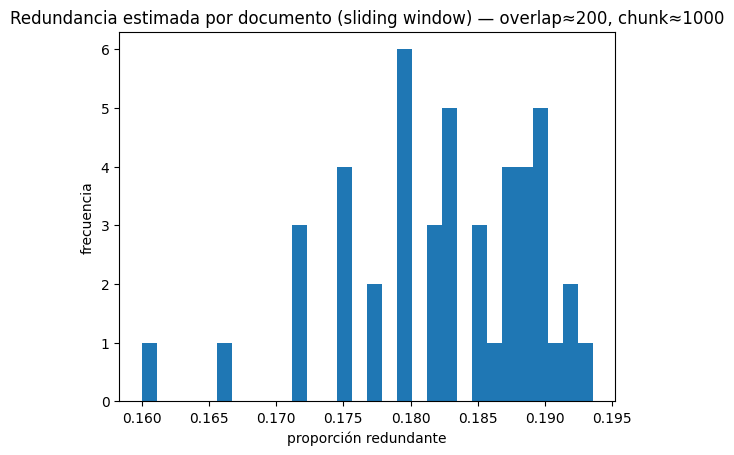

In [11]:
# === Redundancia estimada (solo Sliding Window) ===
# Usa df_chunks_sliding recién creado arriba

import numpy as np
import matplotlib.pyplot as plt

# Reutiliza los mismos parámetros que usaste en chunk_text_sliding_window,
# o, si no están definidos, se estiman desde el DataFrame.
try:
    CHUNK_SIZE
    OVERLAP
except NameError:
    # Estimar tamaño de chunk como mediana de 'length'
    chunk_size_est = float(df_chunks_sliding["length"].median())
    # Estimar stride como mediana de la diferencia de 'start' por documento
    stride_vals = (
        df_chunks_sliding
        .sort_values(["fuente", "chunk_index"])
        .groupby("fuente")["start"]
        .diff()
        .dropna()
    )
    stride_est = float(stride_vals.median())
    CHUNK_SIZE = int(round(chunk_size_est))
    OVERLAP = max(0, int(round(CHUNK_SIZE - stride_est)))

def _redundancia(n, chunk_size, overlap):
    if n <= 1:
        return 0.0
    cobertura_unica = n*chunk_size - (n-1)*overlap
    total_generado = n*chunk_size
    r = 1.0 - (cobertura_unica / total_generado)
    return max(0.0, min(1.0, float(r)))

# n_chunks por documento con df_chunks_sliding
n_chunks_por_doc = (
    df_chunks_sliding
    .groupby("fuente")
    .size()
    .to_numpy()
)

# Redundancia por documento
redu = np.array([_redundancia(int(n), CHUNK_SIZE, OVERLAP) for n in n_chunks_por_doc])

# Plot
plt.figure()
plt.hist(redu, bins=30)
plt.title(f"Redundancia estimada por documento (sliding window) — overlap≈{OVERLAP}, chunk≈{CHUNK_SIZE}")
plt.xlabel("proporción redundante")
plt.ylabel("frecuencia")
plt.show()

#### Recursive chunking 

La diferencia es que intenta mantener límites naturales del texto antes de forzarlo a tamaños fijos. Primero los va dividiendo por separadores más fuertes a más débiles (de texto mas grande hasta caracteres como signos o espacios). Si un fragmento sigue siendo largo, vuelve a dividirlo recursivamente con el siguiente separador. Al final, recombina piezas en chunks de tamaño objetivo



In [12]:
# segmentación recursiva desde data/apuntes_clean_v1.parquet y guardado en data/chunks_recursive_v1.parquet
import os
import re
import pandas as pd
from typing import List

# reutilizamos el loader robusto (pyarrow -> fastparquet)
def load_dataset():
    rutas_intentos = [
        os.path.join('data', 'apuntes_clean_v1.parquet'),
        'apuntes_clean_v1.parquet',
    ]
    ultimo_error = None
    for ruta in rutas_intentos:
        if os.path.exists(ruta):
            try:
                try:
                    return pd.read_parquet(ruta, engine='pyarrow')
                except Exception as e1:
                    print(f"pyarrow falló: {e1}\n→ Intentando con fastparquet…")
                    try:
                        return pd.read_parquet(ruta, engine='fastparquet')
                    except Exception as e2:
                        ultimo_error = (e1, e2)
                        print(f"fastparquet también falló: {e2}")
            except Exception as e:
                ultimo_error = e
    raise RuntimeError(f"No se pudo cargar el dataset .parquet. Último error: {ultimo_error}")


# utilidades -> normalizar espacios y asegurar strings
_ws_re = re.compile(r"\s+")


def _s(text):
    if text is None:
        return ""
    return str(text)

# split recursivo por una lista jerárquica de separadores
def recursive_split(text: str, separators: List[str], max_len: int) -> List[str]:
    text = _s(text).strip()
    if not text:
        return []
    #si ya es corto, devolver tal cual
    if len(text) <= max_len:
        return [text]

    if not separators:
        #sin separadores disponibles -> forzar corte duro
        return [text[i:i+max_len] for i in range(0, len(text), max_len)]

    sep = separators[0]
    rest = separators[1:]

    # dividir por el separador actual, si el separador es espacio simple, usar split(' ')
    if sep == ' ':
        parts = text.split(' ')
        glue = ' '
    else:
        parts = text.split(sep)
        glue = sep

    # si el separador no generó cortes (texto sin ese separador), avanzar al siguiente
    if len(parts) == 1:
        return recursive_split(text, rest, max_len)

    #repartir recursivamente cada parte si excede tamaño
    chunks = []
    current = []
    current_len = 0

    def flush_current():
        nonlocal current, current_len
        if current:
            combined = glue.join(current).strip()
            if combined:
                if len(combined) <= max_len:
                    chunks.append(combined)
                else:
                    #aún grande: bajar a siguiente separador
                    chunks.extend(recursive_split(combined, rest, max_len))
        current = []
        current_len = 0

    for p in parts:
        piece = p.strip()
        if not piece:
            #conserva separador donde sea útil; evitamos cadenas vacías consecutivas
            if current and glue:
                #empuja un separador lógico en la recombinación
                current.append('')
            continue
        prospective_len = (current_len + (len(glue) if current else 0) + len(piece))
        if prospective_len <= max_len:
            #aún cabe en el paquete actual
            if current:
                current.append(piece)
                current_len = prospective_len
            else:
                current = [piece]
                current_len = len(piece)
        else:
            #cierra paquete actual y decide sobre piece
            flush_current()
            if len(piece) <= max_len:
                current = [piece]
                current_len = len(piece)
            else:
                #la pieza sola ya excede: desciende de nivel
                chunks.extend(recursive_split(piece, rest, max_len))
                current = []
                current_len = 0

    flush_current()
    return chunks

#recombina listas de trozos cortos en ventanas con solapamiento, manteniendo tamaño objetivo

def pack_with_overlap(frags: List[str], chunk_size: int, overlap: int) -> List[str]:
    if not frags:
        return []
    #normaliza y filtra vacios
    norm = []
    for f in frags:
        s = _ws_re.sub(' ', _s(f)).strip()
        if s:
            norm.append(s)
    if not norm:
        return []

    chunks = []
    buf = []
    buf_len = 0

    def emit():
        nonlocal buf, buf_len
        if buf:
            out = ' '.join(buf).strip()
            if out:
                chunks.append(out)
        buf = []
        buf_len = 0

    for frag in norm:
        if buf_len == 0:
            buf.append(frag)
            buf_len = len(frag)
            continue
        prospective = buf_len + 1 + len(frag)  # +1 por espacio
        if prospective <= chunk_size:
            buf.append(frag)
            buf_len = prospective
        else:
            #emite actual y aplica solapamiento aproximado por palabras
            emit()
            if overlap > 0 and chunks:
                tail = chunks[-1]
                # toma overlap caracteres desde el final, cortado por palabras
                # Luego extrae últimas palabras para reconstruir contexto
                if len(tail) > overlap:
                    tail_ctx = tail[-overlap:]
                    # evita iniciar en medio de palabra
                    tail_ctx = tail_ctx[tail_ctx.find(' ')+1:] if ' ' in tail_ctx else tail_ctx
                    if tail_ctx:
                        buf = [tail_ctx]
                        buf_len = len(tail_ctx)
                    else:
                        buf = []
                        buf_len = 0
                else:
                    buf = [tail]
                    buf_len = len(tail)
            else:
                buf = []
                buf_len = 0
            # anade el fragmento actual 
            if buf_len == 0:
                buf = [frag]
                buf_len = len(frag)
            else:
                prospective = buf_len + 1 + len(frag)
                if prospective <= chunk_size:
                    buf.append(frag)
                    buf_len = prospective
                else:
                    emit()
                    buf = [frag]
                    buf_len = len(frag)

    emit()
    return chunks

# pipeline carga -> split recursivo -> empaquetado con solapamiento -> DataFrame y guardado

df_docs_frozen = load_dataset()
assert 'texto' in df_docs_frozen.columns, "El dataset cargado debe contener la columna 'texto'"

separators = ["\n\n", "\n", ". ", "; ", ", ", " "]
chunk_size = 1000
overlap = 200

registros = []
for idx, row in df_docs_frozen.iterrows():
    texto = _s(row.get('texto', ''))
    if not texto.strip():
        continue
    # split recursivo por jerarquía de separadores
    frags = recursive_split(texto, separators, max_len=chunk_size)
    # empaquetar con solapamiento para uniformar tamaño objetivo
    chunks = pack_with_overlap(frags, chunk_size=chunk_size, overlap=overlap)

    for c_idx, c in enumerate(chunks):
        registros.append({
            'fuente': row.get('fuente'),
            'semana': row.get('semana'),
            'fecha': row.get('fecha'),
            'apunte': row.get('apunte'),
            'titulo': row.get('titulo'),
            'autor': row.get('autor'),
            'chunk_id': f"rec_{idx}_{c_idx}",
            'chunk_text': c,
            'chunk_len': len(c),
        })

# df de salida
chunks_recursive_df = pd.DataFrame(registros)
print(f" Documentos: {len(df_docs_frozen)} | Chunks generados (rec): {len(chunks_recursive_df)} | Promedio por doc: {len(chunks_recursive_df)/max(1,len(df_docs_frozen)):.2f}")
print(chunks_recursive_df['chunk_len'].describe().round(1))

# guardado robusto en data/chunks_recursive_v1.parquet 
os.makedirs('data', exist_ok=True)
salida = os.path.join('data', 'chunks_recursive_v1.parquet')
try:
    chunks_recursive_df.to_parquet(salida, engine='pyarrow', index=False)
    print(f"Guardado con pyarrow en: {salida}")
except Exception as e1:
    print(f"pyarrow falló: {e1}\n→ Intentando con fastparquet…")
    try:
        chunks_recursive_df.to_parquet(salida, engine='fastparquet', index=False)
        print(f"Guardado con fastparquet en: {salida}")
    except Exception as e2:
        print(f"fastparquet también falló: {e2}")
        raise

 Documentos: 46 | Chunks generados (rec): 988 | Promedio por doc: 21.48
count     988.0
mean      595.1
std       361.9
min       180.0
25%       196.0
50%       836.5
75%       943.2
max      1000.0
Name: chunk_len, dtype: float64
Guardado con pyarrow en: data\chunks_recursive_v1.parquet


# Comparativas entre ambas técnicas

Saca datos de los archivos parquet que se utilizarán al graficar comparativas

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Rutas
p_sliding = "data/chunks_sliding_v1.parquet"
p_recursive = "data/chunks_recursive_v1.parquet"

# Carga con fallback de engine
def read_parquet_any(path):
    try:
        return pd.read_parquet(path, engine="pyarrow")
    except Exception:
        return pd.read_parquet(path, engine="fastparquet")

df_s = read_parquet_any(p_sliding)     # cols: fuente, chunk, length, start, end, chunk_index
df_r = read_parquet_any(p_recursive)   # cols: fuente, chunk_text, chunk_len, chunk_id

# Normaliza nombres para comparar
df_s = df_s.rename(columns={"length":"len_chunk"})
df_r = df_r.rename(columns={"chunk_len":"len_chunk"})

df_s["strategy"] = "sliding"
df_r["strategy"] = "recursive"

# Unificado solo con lo necesario
keep_cols = ["fuente", "len_chunk", "strategy"]
df_all = pd.concat([df_s[keep_cols], df_r[keep_cols]], ignore_index=True)

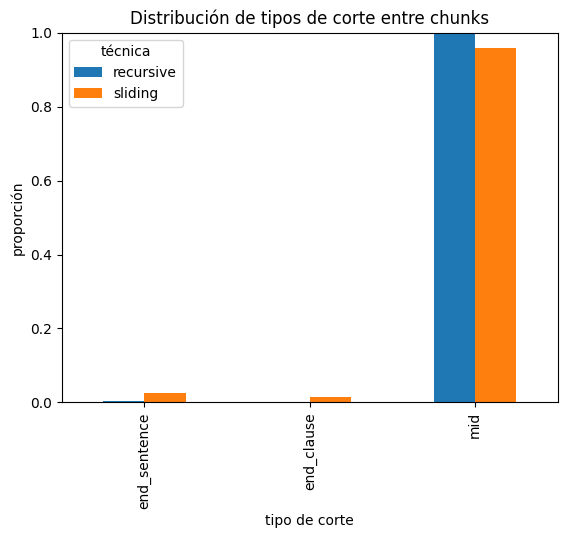

,strategy,boundary_type,count,ratio
4,recursive,end_sentence,4,0.004246
0,recursive,mid,938,0.995754
3,sliding,end_clause,9,0.015679
2,sliding,end_sentence,15,0.026132
1,sliding,mid,550,0.958188


In [34]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# 1) Preparar columnas mínimas: texto y orden por documento
s = df_s.copy()
s["text"] = s.get("chunk", s.get("text", ""))
s["order"] = s.get("chunk_index", 0)

r = df_r.copy()
r["text"] = r.get("chunk_text", r.get("text", ""))
# usa chunk_index si existe; si no, extrae sufijo numérico de chunk_id
if "chunk_index" in r.columns:
    r["order"] = r["chunk_index"]
else:
    r["order"] = r["chunk_id"].astype(str).str.extract(r'_(\d+)$').fillna(0).astype(int)

s["strategy"] = "sliding"
r["strategy"] = "recursive"

keep = ["fuente", "text", "order", "strategy"]
dfb = pd.concat([s[keep], r[keep]], ignore_index=True)

# 2) Clasificación simple del límite entre chunks consecutivos
def classify_boundary(prev_text: str, next_text: str) -> str:
    pt = str(prev_text).rstrip()
    nt = str(next_text).lstrip()
    last = pt[-1] if pt else ""
    if last in ".?!": return "end_sentence"
    if last in ";:,": return "end_clause"
    return "mid"

rows = []
for (fuente, strat), g in dfb.sort_values(["fuente","order"]).groupby(["fuente","strategy"]):
    tx = g["text"].tolist()
    for i in range(len(tx)-1):
        rows.append({"strategy": strat, "boundary_type": classify_boundary(tx[i], tx[i+1])})

stats = pd.DataFrame(rows).value_counts(["strategy","boundary_type"]).rename("count").reset_index()
if not stats.empty:
    stats["ratio"] = stats["count"] / stats.groupby("strategy")["count"].transform("sum")

# 3) Gráfico de barras comparativo
pivot = stats.pivot(index="boundary_type", columns="strategy", values="ratio").fillna(0.0)
pivot = pivot.reindex(["end_sentence","end_clause","mid"])  # orden fijo
pivot.plot(kind="bar")
plt.title("Distribución de tipos de corte entre chunks")
plt.ylabel("proporción")
plt.xlabel("tipo de corte")
plt.ylim(0, 1)
plt.legend(title="técnica")
plt.show()

# (opcional) ver tabla
display(stats.sort_values(["strategy","boundary_type"]))

Comparación de total de chunks y promedio por archivos

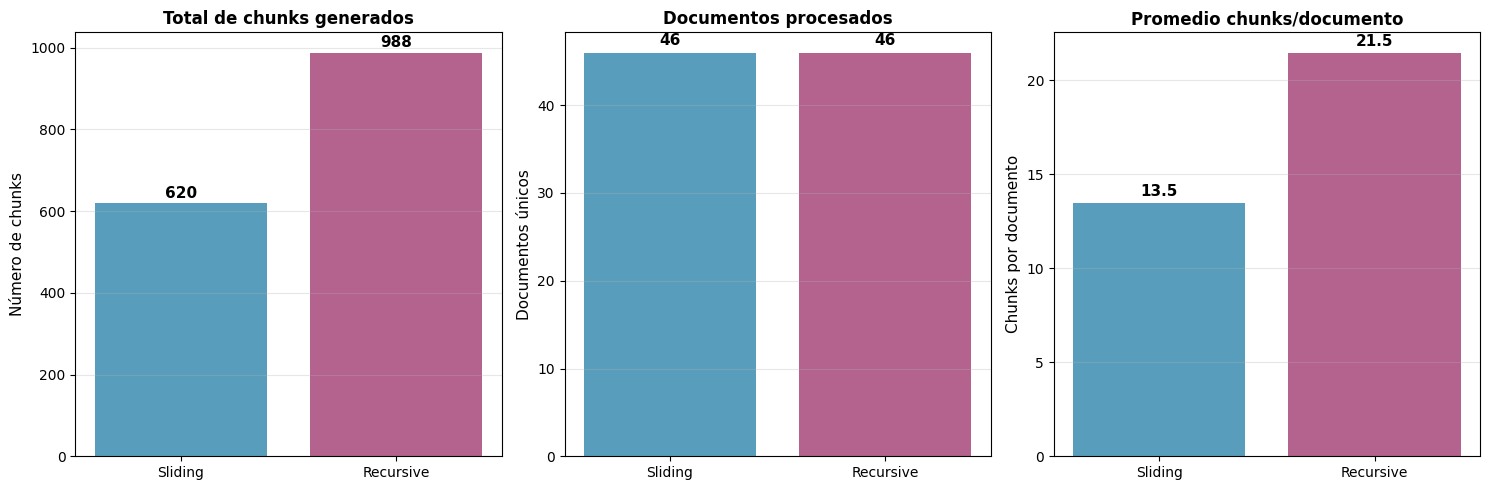

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Total de chunks
total_s = len(df_s)
total_r = len(df_r)
axes[0].bar(['Sliding', 'Recursive'], [total_s, total_r], color=['#2E86AB', '#A23B72'], alpha=0.8)
axes[0].set_ylabel('Número de chunks', fontsize=11)
axes[0].set_title('Total de chunks generados', fontsize=12, fontweight='bold')
for i, v in enumerate([total_s, total_r]):
    axes[0].text(i, v + 5, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Documentos únicos
docs_s = df_s['fuente'].nunique()
docs_r = df_r['fuente'].nunique()
axes[1].bar(['Sliding', 'Recursive'], [docs_s, docs_r], color=['#2E86AB', '#A23B72'], alpha=0.8)
axes[1].set_ylabel('Documentos únicos', fontsize=11)
axes[1].set_title('Documentos procesados', fontsize=12, fontweight='bold')
for i, v in enumerate([docs_s, docs_r]):
    axes[1].text(i, v + 0.5, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Promedio chunks/doc
avg_s = total_s / docs_s
avg_r = total_r / docs_r
axes[2].bar(['Sliding', 'Recursive'], [avg_s, avg_r], color=['#2E86AB', '#A23B72'], alpha=0.8)
axes[2].set_ylabel('Chunks por documento', fontsize=11)
axes[2].set_title('Promedio chunks/documento', fontsize=12, fontweight='bold')
for i, v in enumerate([avg_s, avg_r]):
    axes[2].text(i, v + 0.2, f'{v:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Resumen ejecutivo de ambas técnicas

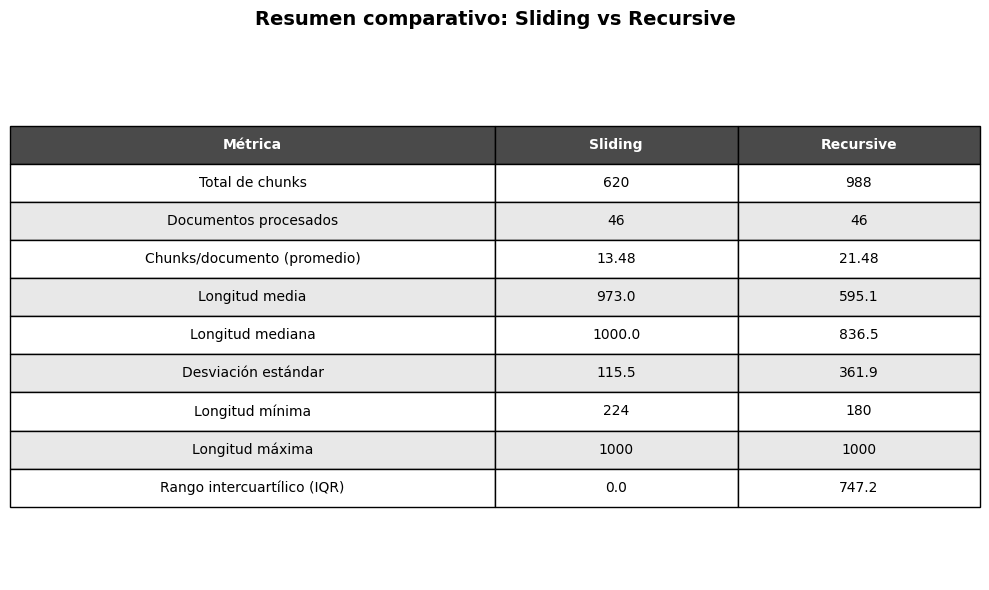

In [16]:
# 10. Resumen ejecutivo en tabla visual
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight')
ax.axis('off')

# Preparar datos de la tabla
metricas = [
    'Total de chunks',
    'Documentos procesados',
    'Chunks/documento (promedio)',
    'Longitud media',
    'Longitud mediana',
    'Desviación estándar',
    'Longitud mínima',
    'Longitud máxima',
    'Rango intercuartílico (IQR)'
]

valores_s = [
    len(df_s),
    df_s['fuente'].nunique(),
    f"{len(df_s) / df_s['fuente'].nunique():.2f}",
    f"{df_s['len_chunk'].mean():.1f}",
    f"{df_s['len_chunk'].median():.1f}",
    f"{df_s['len_chunk'].std():.1f}",
    f"{df_s['len_chunk'].min():.0f}",
    f"{df_s['len_chunk'].max():.0f}",
    f"{df_s['len_chunk'].quantile(0.75) - df_s['len_chunk'].quantile(0.25):.1f}"
]

valores_r = [
    len(df_r),
    df_r['fuente'].nunique(),
    f"{len(df_r) / df_r['fuente'].nunique():.2f}",
    f"{df_r['len_chunk'].mean():.1f}",
    f"{df_r['len_chunk'].median():.1f}",
    f"{df_r['len_chunk'].std():.1f}",
    f"{df_r['len_chunk'].min():.0f}",
    f"{df_r['len_chunk'].max():.0f}",
    f"{df_r['len_chunk'].quantile(0.75) - df_r['len_chunk'].quantile(0.25):.1f}"
]

tabla_data = []
for m, s, r in zip(metricas, valores_s, valores_r):
    tabla_data.append([m, s, r])

tabla = ax.table(cellText=tabla_data, 
                colLabels=['Métrica', 'Sliding', 'Recursive'],
                cellLoc='center',
                loc='center',
                colWidths=[0.5, 0.25, 0.25])

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1, 2)

# Colorear encabezados
for i in range(3):
    tabla[(0, i)].set_facecolor('#4A4A4A')
    tabla[(0, i)].set_text_props(weight='bold', color='white')

# Colorear filas alternadas
for i in range(1, len(metricas) + 1):
    color = '#E8E8E8' if i % 2 == 0 else '#FFFFFF'
    for j in range(3):
        tabla[(i, j)].set_facecolor(color)

plt.title('Resumen comparativo: Sliding vs Recursive', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Chunks por documento

C:\Users\Hp\AppData\Local\Temp\ipykernel_20800\3845030323.py:5: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


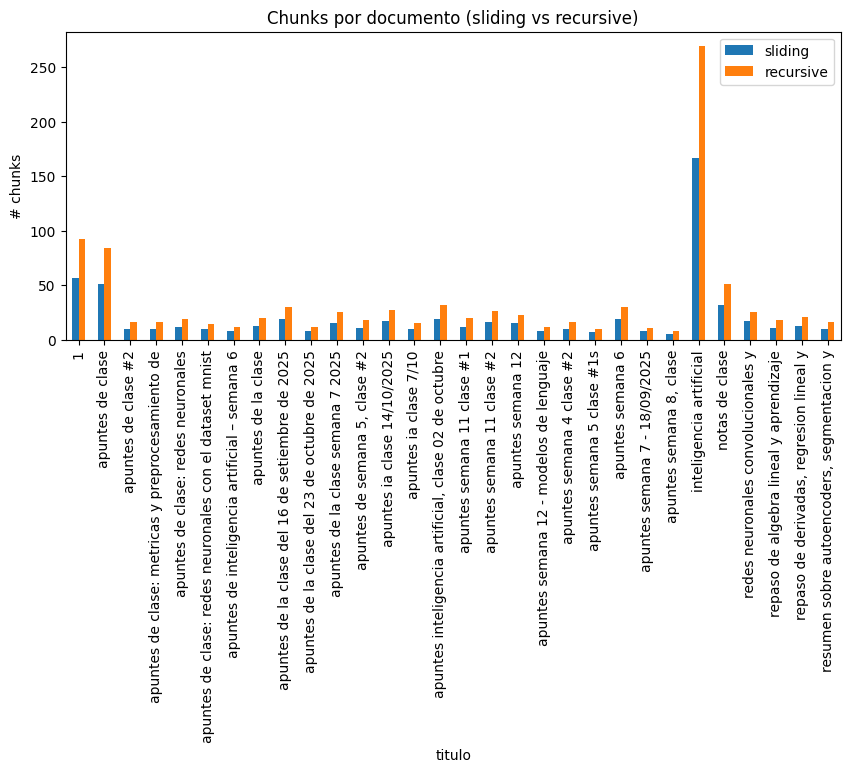

In [17]:
s_counts = df_chunks_sliding.groupby('titulo').size().rename('sliding')
r_counts = chunks_recursive_df.groupby('titulo').size().rename('recursive')
counts = pd.concat([s_counts, r_counts], axis=1).fillna(0).astype(int)
counts.plot(kind='bar', figsize=(10,4), title='Chunks por documento (sliding vs recursive)').set_ylabel('# chunks')
plt.tight_layout()
plt.show()

# Tokenización y Embeddings

In [18]:
!pip install -U pandas pyarrow numpy tqdm tenacity
!pip install -U openai python-dotenv

### Instalación de FAISS para Base de Datos Vectorial

FAISS es una biblioteca de facebook optimizada para búsqueda de similitud en espacios vectoriales. 

In [19]:
# instalar FAISS y tiktoken
!pip install -q faiss-cpu tiktoken

### Configuración del Cliente OpenAI

Para generar embeddings con text-embedding-3-small, se usó una API key válida de OpenAI, el cliente de la librería openai (v1.0+) y un archivo .env con la clave 

In [20]:
import os
from openai import OpenAI
from dotenv import load_dotenv

#cargar variables de entorno desde el archivo .env
load_dotenv()

#eerificar que la API key esté cargada
api_key = os.getenv("OPENAI_API_KEY")

#inicializar cliente OpenAI
try:
    client = OpenAI(api_key=api_key)
    print("Cliente OpenAI inicializado correctamente")
    print(f"Modelo a usar: text-embedding-3-small (1536 dimensiones)")
    print(f"API key cargada desde .env: {api_key[:20]}...{api_key[-4:]}")
except Exception as e:
    print(f"Error al inicializar cliente OpenAI: {e}")
    raise

Cliente OpenAI inicializado correctamente
Modelo a usar: text-embedding-3-small (1536 dimensiones)
API key cargada desde .env: sk-proj-BSJOpTOHcMSe...rc0A


In [21]:
import numpy as np
from typing import List
from tqdm import tqdm
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type
from openai import OpenAI, RateLimitError, APITimeoutError, APIConnectionError

@retry(
    stop=stop_after_attempt(5),
    wait=wait_exponential(multiplier=1, min=2, max=60),
    retry=retry_if_exception_type((RateLimitError, APITimeoutError, APIConnectionError)),
    reraise=True
)
#llamada a la API de embeddings con retry automático
def _call_embedding_api(client: OpenAI, texts: List[str], model: str) -> List[List[float]]:
    response = client.embeddings.create(
        input=texts,
        model=model
    )
    return [item.embedding for item in response.data]


def generate_embeddings_batch(
    texts: List[str],
    client: OpenAI,
    model: str = "text-embedding-3-small",
    batch_size: int = 100,
    normalize: bool = True,
    show_progress: bool = True
) -> np.ndarray:
    
    if not texts:
        return np.array([])
    
    #filtrar textos vacíos y mantener índices originales
    valid_indices = [i for i, t in enumerate(texts) if t and str(t).strip()]
    valid_texts = [texts[i] for i in valid_indices]
    
    if not valid_texts:
        print("Advertencia: todos los textos están vacíos")
        return np.array([])
    
    print(f"Generando embeddings para {len(valid_texts)} textos...")
    print(f"   Modelo: {model}")
    print(f"   Batch size: {batch_size}")
    print(f"   Normalización: {'Sí' if normalize else 'No'}")
    
    all_embeddings = []
    
    #procesar en lotes con progress bar
    iterator = range(0, len(valid_texts), batch_size)
    if show_progress:
        iterator = tqdm(iterator, desc="Generando embeddings", unit="batch")
    
    for i in iterator:
        batch = valid_texts[i:i + batch_size]
        
        try:
            #llamar API con retry automático
            batch_embeddings = _call_embedding_api(client, batch, model)
            all_embeddings.extend(batch_embeddings)
            
        except Exception as e:
            print(f"\nError en batch {i//batch_size + 1}: {e}")
            raise
    
    #convertir a numpy array
    embeddings_array = np.array(all_embeddings, dtype=np.float32)
    
    #normalizar si se solicita (requerido para cosine similarity con FAISS)
    if normalize:
        norms = np.linalg.norm(embeddings_array, axis=1, keepdims=True)
        embeddings_array = embeddings_array / norms
    
    print(f"Embeddings generados: shape {embeddings_array.shape}")
    print(f"   Rango de valores: [{embeddings_array.min():.4f}, {embeddings_array.max():.4f}]")
    
    #si había textos vacíos, crear array completo con zeros en posiciones vacías
    if len(valid_indices) < len(texts):
        full_embeddings = np.zeros((len(texts), embeddings_array.shape[1]), dtype=np.float32)
        full_embeddings[valid_indices] = embeddings_array
        return full_embeddings
    
    return embeddings_array

### Función para Generar Embeddings en Lotes

Esta función procesa los textos por request, si se dieran errores, usa tenacity.
Hicimos que muestre el progreso con tqdm para visualizar el avance (algo estetico, no primordial).
Los vectores se normalizan para usar cosine similarity con FAISS

Parámetros:
- texts: Lista de strings a convertir en embeddings
- model: Modelo de OpenAI 
- batch_size: Cantidad de textos por request 
- normalize: Si normalizar vectores para cosine similarity 

In [22]:
import faiss
import json
import os
import pandas as pd

# cargar chunks desde data/chunks_sliding_v1.parquet
print("PROCESANDO CHUNKS SLIDING WINDOW")

ruta_chunks_sliding = os.path.join("data", "chunks_sliding_v1.parquet")

try:
    df_sliding = pd.read_parquet(ruta_chunks_sliding, engine="fastparquet")
    print(f"Chunks cargados: {len(df_sliding)} registros")
    print(f"   Columnas: {list(df_sliding.columns)}")
except Exception as e:
    print(f" Error al cargar chunks: {e}")
    raise

#extraer textos de la columna 'chunk'
texts_sliding = df_sliding["chunk"].tolist()
print(f" Textos a procesar: {len(texts_sliding)}")

#generar embeddings para los chunks con ventana deslizante
print("GENERANDO EMBEDDINGS")

embeddings_sliding = generate_embeddings_batch(
    texts=texts_sliding,
    client=client,
    model="text-embedding-3-small",
    batch_size=100,
    normalize=True,
    show_progress=True
)

print(f"\n Embeddings generados: {embeddings_sliding.shape}")

# crear indice FAISS para los embeddings generados
print("CREANDO ÍNDICE FAISS")

# dimension de los embeddings 
dimension = embeddings_sliding.shape[1]

# crear indice FAISS con producto interno
index_sliding = faiss.IndexFlatIP(dimension)

# agregar vectores al indice
index_sliding.add(embeddings_sliding)

print(f" Índice FAISS creado")
print(f"   Tipo: IndexFlatIP (Inner Product / Cosine Similarity)")
print(f"   Dimensión: {index_sliding.d}")
print(f"   Vectores almacenados: {index_sliding.ntotal}")

# guardar indice y metadata
print("GUARDANDO ÍNDICE Y METADATA")

# crear directorio vectordb
os.makedirs("vectordb", exist_ok=True)

# guardar índice FAISS
index_path = os.path.join("vectordb", "faiss_index_sliding.bin")
faiss.write_index(index_sliding, index_path)
print(f" Índice guardado: {index_path}")

# guardar metadata (información de los chunks para recuperación)
metadata_sliding = {
    "index_type": "IndexFlatIP",
    "dimension": dimension,
    "total_vectors": int(index_sliding.ntotal),
    "model": "text-embedding-3-small",
    "chunking_method": "fixed-size sliding window",
    "chunk_size": 1000,
    "overlap": 200,
    "normalized": True,
    "columns": list(df_sliding.columns),
    "created_at": pd.Timestamp.now().isoformat()
}

metadata_path = os.path.join("vectordb", "faiss_index_sliding_metadata.json")
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata_sliding, f, indent=2, ensure_ascii=False)
print(f" Metadata guardada: {metadata_path}")

# guardar backup con embeddings
print("GUARDANDO BACKUP CON EMBEDDINGS")

# agregar embeddings al DataFrame como nueva columna
df_sliding_with_embeddings = df_sliding.copy()
df_sliding_with_embeddings["embedding"] = list(embeddings_sliding)

backup_path = os.path.join("data", "embeddings_sliding_v1.parquet")
df_sliding_with_embeddings.to_parquet(backup_path, engine="pyarrow", index=False)
print(f" Backup guardado: {backup_path}")

# resumen final
print(" PROCESAMIENTO COMPLETADO: CHUNKS SLIDING WINDOW")
print(f" Chunks procesados: {len(df_sliding)}")
print(f" Embeddings generados: {embeddings_sliding.shape}")
print(f"  Índice FAISS: {index_sliding.ntotal} vectores")
print(f"   - {index_path}")
print(f"   - {metadata_path}")
print(f"   - {backup_path}")

PROCESANDO CHUNKS SLIDING WINDOW
Chunks cargados: 620 registros
   Columnas: ['fuente', 'semana', 'fecha', 'apunte', 'titulo', 'autor', 'chunk_index', 'start', 'end', 'length', 'chunk']
 Textos a procesar: 620
GENERANDO EMBEDDINGS
Generando embeddings para 620 textos...
   Modelo: text-embedding-3-small
   Batch size: 100
   Normalización: Sí
Chunks cargados: 620 registros
   Columnas: ['fuente', 'semana', 'fecha', 'apunte', 'titulo', 'autor', 'chunk_index', 'start', 'end', 'length', 'chunk']
 Textos a procesar: 620
GENERANDO EMBEDDINGS
Generando embeddings para 620 textos...
   Modelo: text-embedding-3-small
   Batch size: 100
   Normalización: Sí


Generando embeddings: 100%|██████████| 7/7 [00:13<00:00,  1.89s/batch]



Embeddings generados: shape (620, 1536)
   Rango de valores: [-0.1570, 0.1852]

 Embeddings generados: (620, 1536)
CREANDO ÍNDICE FAISS
 Índice FAISS creado
   Tipo: IndexFlatIP (Inner Product / Cosine Similarity)
   Dimensión: 1536
   Vectores almacenados: 620
GUARDANDO ÍNDICE Y METADATA
 Índice guardado: vectordb\faiss_index_sliding.bin
 Metadata guardada: vectordb\faiss_index_sliding_metadata.json
GUARDANDO BACKUP CON EMBEDDINGS
 Backup guardado: data\embeddings_sliding_v1.parquet
 PROCESAMIENTO COMPLETADO: CHUNKS SLIDING WINDOW
 Chunks procesados: 620
 Embeddings generados: (620, 1536)
  Índice FAISS: 620 vectores
   - vectordb\faiss_index_sliding.bin
   - vectordb\faiss_index_sliding_metadata.json
   - data\embeddings_sliding_v1.parquet


### Procesamiento de Chunks Sliding Window
Primero se guarda el archivo data/chunks_sliding_v1.parquet. Luego generaremos los embeddings para cada chunck usando OpenAI. Luego se crea el índice FAISS (IndexFlatIP para cosine similarity) y se guardan los resultados.
   - Índice FAISS: vectordb/faiss_index_sliding.bin
   - Metadata JSON: vectordb/faiss_index_sliding_metadata.json
   - Backup con embeddings: data/embeddings_sliding_v1.parquet

In [23]:
import faiss
import json
import os
import pandas as pd

# cargar chunks desde data/chunks_recursive_v1.parquet
print("PROCESANDO CHUNKS RECURSIVE")

ruta_chunks_recursive = os.path.join("data", "chunks_recursive_v1.parquet")

try:
    df_recursive = pd.read_parquet(ruta_chunks_recursive, engine="fastparquet")
    print(f" Chunks cargados: {len(df_recursive)} registros")
    print(f"   Columnas: {list(df_recursive.columns)}")
except Exception as e:
    print(f" Error al cargar chunks: {e}")
    raise

# extraer textos de la columna 'chunk_text' (nota: diferente nombre que sliding)
texts_recursive = df_recursive["chunk_text"].tolist()
print(f" Textos a procesar: {len(texts_recursive)}")

# generar embeddings para los chunks recursivos
print("GENERANDO EMBEDDINGS")

embeddings_recursive = generate_embeddings_batch(
    texts=texts_recursive,
    client=client,
    model="text-embedding-3-small",
    batch_size=100,
    normalize=True,
    show_progress=True
)

print(f"\n Embeddings generados: {embeddings_recursive.shape}")

# crear indice FAISS para los embeddings generados
print("CREANDO ÍNDICE FAISS")

# dimension de los embeddings
dimension = embeddings_recursive.shape[1]

# crear indice FAISS con producto interno
index_recursive = faiss.IndexFlatIP(dimension)

# agregar vectores al indice
index_recursive.add(embeddings_recursive)

print(f" Índice FAISS creado")
print(f"   Tipo: IndexFlatIP (Inner Product / Cosine Similarity)")
print(f"   Dimensión: {index_recursive.d}")
print(f"   Vectores almacenados: {index_recursive.ntotal}")

#guardar indece y metadata
print("GUARDANDO ÍNDICE Y METADATA")

#crear directorio vectordb (ya existe, pero por si acaso)
os.makedirs("vectordb", exist_ok=True)

#guardar indice FAISS
index_path = os.path.join("vectordb", "faiss_index_recursive.bin")
faiss.write_index(index_recursive, index_path)
print(f" Índice guardado: {index_path}")

#guardar metadata
metadata_recursive = {
    "index_type": "IndexFlatIP",
    "dimension": dimension,
    "total_vectors": int(index_recursive.ntotal),
    "model": "text-embedding-3-small",
    "chunking_method": "recursive text splitter",
    "chunk_size": 1000,
    "overlap": 200,
    "separators": ["\n\n", "\n", ". ", "; ", ", ", " "],
    "normalized": True,
    "columns": list(df_recursive.columns),
    "created_at": pd.Timestamp.now().isoformat()
}

metadata_path = os.path.join("vectordb", "faiss_index_recursive_metadata.json")
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata_recursive, f, indent=2, ensure_ascii=False)
print(f" Metadata guardada: {metadata_path}")

#guardar backup con embeddings (parquet)
print("GUARDANDO BACKUP CON EMBEDDINGS")

#anadir embeddings al DataFrame como nueva columna
df_recursive_with_embeddings = df_recursive.copy()
df_recursive_with_embeddings["embedding"] = list(embeddings_recursive)

backup_path = os.path.join("data", "embeddings_recursive_v1.parquet")
df_recursive_with_embeddings.to_parquet(backup_path, engine="pyarrow", index=False)
print(f" Backup guardado: {backup_path}")

#imprimir resumen final
print(" PROCESAMIENTO COMPLETADO: CHUNKS RECURSIVE")
print(f" Chunks procesados: {len(df_recursive)}")
print(f" Embeddings generados: {embeddings_recursive.shape}")
print(f"  Índice FAISS: {index_recursive.ntotal} vectores")
print(f"\n Archivos generados:")
print(f"   - {index_path}")
print(f"   - {metadata_path}")
print(f"   - {backup_path}")


PROCESANDO CHUNKS RECURSIVE
 Chunks cargados: 988 registros
   Columnas: ['fuente', 'semana', 'fecha', 'apunte', 'titulo', 'autor', 'chunk_id', 'chunk_text', 'chunk_len']
 Textos a procesar: 988
GENERANDO EMBEDDINGS
Generando embeddings para 988 textos...
   Modelo: text-embedding-3-small
   Batch size: 100
   Normalización: Sí


Generando embeddings: 100%|██████████| 10/10 [00:15<00:00,  1.54s/batch]


Embeddings generados: shape (988, 1536)
   Rango de valores: [-0.1614, 0.1803]

 Embeddings generados: (988, 1536)
CREANDO ÍNDICE FAISS
 Índice FAISS creado
   Tipo: IndexFlatIP (Inner Product / Cosine Similarity)
   Dimensión: 1536
   Vectores almacenados: 988
GUARDANDO ÍNDICE Y METADATA
 Índice guardado: vectordb\faiss_index_recursive.bin
 Metadata guardada: vectordb\faiss_index_recursive_metadata.json
GUARDANDO BACKUP CON EMBEDDINGS
 Backup guardado: data\embeddings_recursive_v1.parquet
 PROCESAMIENTO COMPLETADO: CHUNKS RECURSIVE
 Chunks procesados: 988
 Embeddings generados: (988, 1536)
  Índice FAISS: 988 vectores

 Archivos generados:
   - vectordb\faiss_index_recursive.bin
   - vectordb\faiss_index_recursive_metadata.json
   - data\embeddings_recursive_v1.parquet


## tools

### web tool

In [24]:
from pathlib import Path

code = """"""

ruta = Path("app/web_tool.py")
ruta.parent.mkdir(parents=True, exist_ok=True)
ruta.write_text(code, encoding="utf-8")

print(f"archivo creado: {ruta.resolve()}")

archivo creado: C:\Users\Hp\Desktop\Inteligencia Artificial\Tarea-1-v2\Tarea-1-IA\app\web_tool.py


In [25]:
%%writefile app/web_tool.py
from typing import List, Dict
from ddgs import DDGS

__all__ = ["search_web"]


# realiza una búsqueda  en DuckDuckGo y devuelve resultados 
def search_web(query: str, limit: int = 5) -> List[Dict[str, str]]:
 
    #comprobar si DDGS está disponible
    if DDGS is None:
        raise RuntimeError(
            "'ddgs' no está instalado"
        )

    # validar params
    if not isinstance(query, str) or not query.strip():
        raise ValueError("la consulta 'query' debe ser una cadena no vacía")

    # limitar el num de resultados
    if not isinstance(limit, int) or limit < 1 or limit >= 11:
        raise ValueError("el parámetro 'limit' debe ser un entero entre 1 y 10")

    try:
        with DDGS() as ddgs:
            results = ddgs.text(query, max_results=limit)
    except Exception as e:
        raise RuntimeError(f"Error ejecutando la búsqueda en DuckDuckGo: {e}") from e

    if not results:
        return []

    # dar resultados
    out: List[Dict[str, str]] = []
    for r in results:
        out.append({
            "title": r.get("title", ""),
            "snippet": r.get("body", ""),
            "url": r.get("href", "")
        })

    return out

Overwriting app/web_tool.py


### rag tool

In [26]:
from pathlib import Path

code = """"""

ruta = Path("app/rag_tool.py")
ruta.parent.mkdir(parents=True, exist_ok=True)
ruta.write_text(code, encoding="utf-8")

print(f"archivo creado: {ruta.resolve()}")

archivo creado: C:\Users\Hp\Desktop\Inteligencia Artificial\Tarea-1-v2\Tarea-1-IA\app\rag_tool.py


In [27]:
%%writefile app/rag_tool.py
import os
import json
import numpy as np
import pandas as pd
import faiss
from typing import List, Dict, Tuple
from openai import OpenAI
from pathlib import Path

#detecta la raíz del proyecto y las carpetas data/ y vectordb/
def get_project_paths() -> Tuple[str, str, str]:
    here = Path(__file__).resolve()
    for parent in here.parents:
        if (parent / "vectordb").exists() or (parent / "data").exists():
            return str(parent), str(parent / "data"), str(parent / "vectordb")
    fallback = here.parent.parent.parent
    return str(fallback), str(fallback / "data"), str(fallback / "vectordb")


#esto carga el indice FAISS y el DataFrame (ya sea sliding o recursive)
def load_index_and_df(strategy: str):
    base_dir, data_dir, vectordb_dir = get_project_paths()
    if strategy == "sliding":
        index_path = os.path.join(vectordb_dir, "faiss_index_sliding.bin")
        df_path = os.path.join(data_dir, "chunks_sliding_v1.parquet")
        text_col = "chunk"
        meta_name = "faiss_index_sliding_metadata.json"
    else:
        index_path = os.path.join(vectordb_dir, "faiss_index_recursive.bin")
        df_path = os.path.join(data_dir, "chunks_recursive_v1.parquet")
        text_col = "chunk_text"
        meta_name = "faiss_index_recursive_metadata.json"

    index = faiss.read_index(index_path)
    try:
        df = pd.read_parquet(df_path, engine="pyarrow")
    except Exception:
        df = pd.read_parquet(df_path, engine="fastparquet")

    metadata = None
    meta_path = os.path.join(vectordb_dir, meta_name)
    try:
        with open(meta_path, "r", encoding="utf-8") as f:
            metadata = json.load(f)
    except Exception:
        pass

    return index, df, text_col, metadata

#generar embedding normalizado para la query
def embed_query(client: OpenAI, text: str) -> np.ndarray:
    resp = client.embeddings.create(model="text-embedding-3-small", input=[text])
    emb = np.array([resp.data[0].embedding], dtype=np.float32)
    # normalizar L2 (RECORDAR QUE los indices fueron creados con vectores normalizados)
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    emb = emb / np.clip(norms, 1e-12, None)
    return emb


#funcion que busca top-k chunks en el indice seleccionado -> construye contexto 
#return (resultados, contexto_etiquetado)
def retrieve_from_index(
    client: OpenAI,
    query: str,
    strategy: str,
    k: int = 5,
) -> Tuple[List[Dict], str]:
    index, df, text_col, metadata = load_index_and_df(strategy)
    q_emb = embed_query(client, query)
    distances, indices = index.search(q_emb, k)

    resultados: List[Dict] = []
    etiquetas_contexto = []

    for rank, (idx, score) in enumerate(zip(indices[0], distances[0]), start=1):
        if idx == -1:
            continue
        row = df.iloc[int(idx)]
        fuente = row.get("fuente", "")
        autor = row.get("autor", "")
        semana = row.get("semana", "")
        fecha = row.get("fecha", "")
        titulo = row.get("titulo", "")
        texto = str(row.get(text_col, ""))
        preview = (texto[:300] + "...") if len(texto) > 300 else texto

        resultados.append({
            "rank": rank,
            "score": float(score),
            "fuente": fuente,
            "autor": autor,
            "semana": semana,
            "fecha": fecha,
            "titulo": titulo,
            "texto": texto,
            "preview": preview,
            "row_index": int(idx),
        })
        etiquetas_contexto.append(f"[{rank}] Fuente: {fuente} | Autor: {autor} | Semana: {semana} | Título: {titulo}\n{texto}\n")

    contexto = "\n\n".join(etiquetas_contexto)
    return resultados, contexto


Overwriting app/rag_tool.py


## app

In [28]:
from pathlib import Path

code = """"""

ruta = Path("app/app.py")
ruta.parent.mkdir(parents=True, exist_ok=True)
ruta.write_text(code, encoding="utf-8")

print(f"archivo creado: {ruta.resolve()}")

archivo creado: C:\Users\Hp\Desktop\Inteligencia Artificial\Tarea-1-v2\Tarea-1-IA\app\app.py


### configuración de .env

In [29]:
%%writefile app/app.py
import os
import streamlit as st
from openai import OpenAI
from typing import List, Dict
from pathlib import Path

from rag_tool import load_index_and_df, retrieve_from_index
from web_tool import search_web

try:
    from dotenv import load_dotenv, find_dotenv
    load_dotenv(find_dotenv())
except Exception:
    print("No se pudo cargar el archivo .env!")


# conf de pag
st.set_page_config(page_title="Agente IA", page_icon="")
st.title("ChatMMI")

# api_key
API_KEY = os.getenv("OPENAI_API_KEY")
if not API_KEY:
    st.sidebar.error("Falta API_KEY")
    st.stop()

client = OpenAI(api_key=API_KEY, base_url="https://api.openai.com/v1")

Overwriting app/app.py


### configuración de bot

In [30]:
%%writefile -a app/app.py
try:
    models = client.models.list()
    st.sidebar.success("Conexión con OpenAI establecida")
except Exception as e:
    st.sidebar.error(f"Error de conexión: {str(e)}")
    st.stop()

SYSTEM_PROMPT = """
Eres un asistente académico llamado Astra, especializado en Inteligencia Artificial.
Tu tarea es responder preguntas sobre Inteligencia Artificial y temas relacionados.
Debes responder siempre de manera clara, directa y con tono formal.
Si no tienes información suficiente para responder una pregunta, indícalo.
Cuando la información solicitada exista en los apuntes o documentos disponibles, 
debes basar tu respuesta en ellos e indicar el documento y autor de referencia. 
Si no se encuentra información relevante en los apuntes, 
debes indicarlo explícitamente antes de responder con tu conocimiento general, 
manteniendo siempre la precisión y el tono académico.
No debes utilizar herramientas de búsqueda en internet ni consultar fuentes externas,
a menos que el usuario lo solicite de forma explícita.
"""

Appending to app/app.py


### limpiar inputs para busqueda

In [31]:
%%writefile -a app/app.py
import re
def clean_search_query(query: str) -> str:
    #lista de palabras y frases comunes a eliminar
    stopwords = [
        'dame', 'dime', 'que es', 'qué es', 'cual es', 'cuál es', 'como es', 'cómo es',
        'cuales son', 'cuáles son', 'como son', 'cómo son', 'me puedes', 'puedes',
        'explicame', 'explícame', 'explica', 'dime sobre', 'dame información',
        'quiero saber', 'necesito saber', 'me gustaría', 'quisiera',
        'por favor', 'gracias', 'hola', 'ayudame', 'ayúdame', "quien es", "quien fue", "quién es", "quién fue", 
        "¿", 'que','qué','cual','cuál','cuales','cuáles','cuando','cuándo','donde',
        'dónde','por que','por qué','porque','para que','para qué','como','cómo',
        'quien','quién','quienes','quiénes','cuanto','cuánto','cuantos','cuántos',
        'cuanta','cuánta','cuantas','cuántas','si puedes','si pudieras','si fuese posible','seria posible',
        'sería posible','te agradecería','agradeceria','agradecería','gracias',
        'muchas gracias','hola','buenas','buenas tardes','buenas noches','buen día',
        'buenos dias','buenos días','saludos','estimado','dias','días','noches',"tardes",
        'estimado','queria','quería','quisiera saber','me gustaria saber',
        'me gustaría saber','podrias explicar','podrías explicar',
        'podrias decirme','podrías decirme','podrias darme','podrías darme','ahora','busca'
    ]
    
    query_lower = query.lower()
    cleaned = query
    
    #remove stopwords
    # eliminar todas las frases stop sin importar posición
    for phrase in stopwords:
        # usa regex para eliminar la frase completa 
        pattern = r'\b' + re.escape(phrase) + r'\b'
        cleaned = re.sub(pattern, '', cleaned)

    # eliminar espacios duplicados o basura
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()


    # ESTO SE PUEDE ACTIVAR O NO 
    #if len(cleaned) < 3: #si queda muy corto -> usar original
     #   return query
    
    return cleaned

Appending to app/app.py


### aplicacion con bot

In [32]:
%%writefile -a app/app.py
#Inicializar estado de la sesión
if "messages" not in st.session_state:
    st.session_state.messages = []

#CONTROLES EN SIDEBAR
st.sidebar.markdown("---")
#RAG
st.sidebar.subheader("RAG (Apuntes del curso)")
rag_enabled = st.sidebar.checkbox("Usar RAG con base vectorial", value=True)
rag_strategy_label = st.sidebar.radio(
    "Fuente de RAG",
    ["Sliding window", "Recursive"],
    index=0,
    disabled=not rag_enabled,
)
rag_strategy = "sliding" if rag_strategy_label.startswith("Sliding") else "recursive"
rag_k = st.sidebar.slider("Resultados RAG (k)", min_value=1, max_value=10, value=5, disabled=not rag_enabled)

#intento de precarga para informar estado

#precarga para informar estado
if rag_enabled:
    try:
        idx_tmp, df_tmp, text_col_tmp, meta_tmp = load_index_and_df(rag_strategy)
        st.sidebar.success(f"Índice RAG cargado: {idx_tmp.ntotal} vectores")
    except Exception as e:
        st.sidebar.warning(f"No se pudo cargar el índice RAG: {e}")

st.sidebar.markdown("---")
st.sidebar.subheader("Configuración de Búsqueda Web")
use_web = st.sidebar.checkbox("Buscar en la web antes de responder", value=False)
web_limit = st.sidebar.slider("Número de resultados web", min_value=1, max_value=10, value=3)

#Mostrar mensajes anteriores
for msg in st.session_state.messages:
    with st.chat_message(msg["role"]):
        st.markdown(msg["content"])


#CONFIGURACION DEL WEB TOOL
max_recent_web_context = 3  # número máximo de interacciones recientes para contexto web

#input del usuario
user_input = st.chat_input("Escribe tu pregunta...")

if user_input:
    #mostrar mensaje del usuario
    st.chat_message("user").markdown(user_input)
    st.session_state.messages.append({"role": "user", "content": user_input})

    web_context = None
    rag_context = None
    rag_sources: List[Dict] = []

    # RAG (búsqueda en apuntes)
    if rag_enabled:
        try:
            with st.spinner("Buscando en apuntes (RAG)..."):
                rag_sources, rag_context = retrieve_from_index(client, user_input, rag_strategy, rag_k)
        except Exception as e:
            st.warning(f"RAG desactivado por error: {e}")
            rag_context = None
            rag_sources = []

        # mostrar resultados RAG
        if rag_sources:
            with st.expander("Resultados RAG (apuntes)", expanded=True):
                for r in rag_sources:
                    st.markdown(f"**[{r['rank']}]** Score: {r['score']:.4f} | Fuente: {r['fuente']} | Autor: {r['autor']} | Semana: {r['semana']}")
                    st.markdown(r["preview"])
                    st.markdown("---")

    #buscar en la web si está activado
    if use_web:
        # construir query contextualizada -> si hay historial web reciente -> agregar contexto
        search_query = user_input
        if len(st.session_state.messages) >= max_recent_web_context:
            # tomar los últimos 2 mensajes del usuario para contexto
            recent_context = []
            for msg in st.session_state.messages[-(max_recent_web_context*2):]:  # ultimos mensajes (2 pares usuario-asistente)
                if msg["role"] == "user":
                    recent_context.append(msg["content"])
            
            if recent_context:
                # combinar contexto reciente con la pregunta actual
                search_query = f"{' '.join(recent_context[-max_recent_web_context:])} {user_input}" #ESTO HACE QUE SE DUPLIQUE LA ULTIMA PREGUNTA EN LA BUSQUEDA WEB, NO HAY MUCHO PROBLEMA
        
        #limpiar la query removiendo palabras innecesarias
        cleaned_query = clean_search_query(search_query)
        
        try:
            with st.spinner(f"Buscando: '{cleaned_query[:60]}...'"):
                results = search_web(cleaned_query, limit=web_limit)
        except RuntimeError as e:
            st.warning(str(e))
            results = []
        except Exception as e:
            st.error(f"Error buscando en la web: {e}")
            results = []

        # mostrar resultados
        if not results:
            st.info("No se encontraron resultados en la web para la consulta.")
        else:
            # mostrar el query limpio que se usó
            expander_title = f"Resultados de búsqueda: '{cleaned_query[:50]}...'"
            
            with st.expander(expander_title, expanded=True):
                for i, r in enumerate(results, start=1):
                    st.markdown(f"**{i}. {r.get('title', 'Sin título')}**")
                    if r.get('snippet'):
                        st.markdown(r.get('snippet'))
                    if r.get('url'):
                        st.markdown(f"[{r.get('url')}]({r.get('url')})")
                    st.markdown("---")

            #construir contexto para el modelo
            lines = []
            for i, r in enumerate(results, start=1):
                title = r.get('title', '')
                snippet = r.get('snippet', '')
                url = r.get('url', '')
                lines.append(f"{i}. {title}\n{snippet}\nFuente: {url}\n")
            web_context = "\n".join(lines)

    #construir mensajes del chat
    chat_messages = [{"role": "system", "content": SYSTEM_PROMPT}]

    if rag_context:
        chat_messages.append({
            "role": "system",
            "content": (
                "Contexto documental (apuntes del curso). Usa este contenido como fuente principal para responder.\n"
                "Incluye citas en el formato [n] cuando corresponda y no inventes fuentes.\n\n"
                + rag_context
            ),
        })

    if web_context:
        web_message = f"[Información de búsqueda web para tu consulta]\n\n{web_context}"
        st.session_state.messages.append({
            "role": "system",
            "content": web_message
        })
    
    #construir mensajes del chat
    chat_messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    chat_messages += st.session_state.messages

    # generar respuesta
    try:
        with st.chat_message("assistant"):
            with st.spinner("Pensando..."):
                chat_completion = client.chat.completions.create(
                    model="gpt-3.5-turbo-0125",
                    messages=chat_messages
                )

                response_content = chat_completion.choices[0].message.content
                st.markdown(response_content)
                st.session_state.messages.append({"role": "assistant", "content": response_content})

                #mostrar fuentes RAG debajo 
                if rag_sources:
                    st.markdown("\n**Fuentes citadas (RAG):**")
                    for r in rag_sources:
                        st.markdown(f"- [{r['rank']}] {r['fuente']} — Autor: {r['autor']} — Semana: {r['semana']}")

    except Exception as e:
        st.error(f"Error generando respuesta: {str(e)}")

Appending to app/app.py


In [33]:
!streamlit run app/app.py

^C
